# **Classifying rice grain images using machine learning algorithms**

Objective: Compare different classifiers on rice grain images dataset, using only the morphological and shape features of the rice grains.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV

# Load the dataset
# This dataset is from Koklu, M.'s repository (2021) in https://www.muratkoklu.com/datasets/
data = pd.DataFrame(pd.read_csv(r"Rice_MSC_Dataset.csv"), columns = ["ECCENTRICITY", "ROUNDNESS", "COMPACTNESS", "ASPECT_RATIO", "SHAPEFACTOR_3", "CLASS"])  # Get only the effective features according to Cinar and Koklu (2021)

# Display the first few rows
print("Rice MSC Dataset:")
print(data.head())

# Clean the data by removing rows with NaN
data = data.dropna()

# Split the dataset into training and testing sets
# This dataset has 106 features consisting of rice grain area, roundess, eccentricity, and etc.
# Consider only the features pertaining to the morphology shape of the rice grain
# There are 5 class labels pertaining to the kind of rice: Jasmine, Arborio, Ipsala, Basmati, Karacadag
X = np.array(data.iloc[:, :5])  # Get only the effective features, numpy arrays are faster, change index here depending on the number of features to explore
y = data["CLASS"]  # Get only the labels

# Encode the labels. Represent the strings Jasmine, Arborio, Ipsala, Basmati, Karacadag into integers
encoder = LabelEncoder()
Y = encoder.fit_transform(y)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state = 104, test_size = 0.30, shuffle = True)  # Do a 70-30 split of train and test sets

# Check if we have a balanced training set
from collections import Counter
print("\nNumber of instances per class in data set:")
print(Counter(Y))
print("Dataset is balanced.")

Rice MSC Dataset:
   ECCENTRICITY  ROUNDNESS  COMPACTNESS  ASPECT_RATIO  SHAPEFACTOR_3    CLASS
0        0.9735     0.5114       0.4751        4.3693         0.2257  Basmati
1        0.8632     0.8120       0.7065        1.9807         0.4992  Arborio
2        0.9447     0.6505       0.5689        3.0482         0.3236  Jasmine
3        0.9671     0.5256       0.5007        3.9325         0.2507  Basmati
4        0.8732     0.7944       0.6932        2.0519         0.4806  Arborio

Number of instances per class in data set:
Counter({np.int64(1): 15000, np.int64(0): 15000, np.int64(3): 15000, np.int64(2): 15000, np.int64(4): 15000})
Dataset is balanced.


## **Hyperparameters tuning**

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV

# Define the models and hyperparameters to tune
# Create a dictionary of the classifiers
models = {"Naive Bayes": GaussianNB(),
          "MLP": MLPClassifier(max_iter = 1000),
          "AdaBoost": AdaBoostClassifier(),
          "SVM": SVC(),
          "Random Forest": RandomForestClassifier()}

# Define parameter grids for each model
# Create a dictionary of the hyperparamters to tune for each model
param_grids = {"Naive Bayes": {"var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]},
               "MLP": {"hidden_layer_sizes": [(128, 64), (256, 128), (256, 64)], "activation": ["relu", "tanh"], "solver": ["adam", "sgd"]},
               "AdaBoost": {"n_estimators": [50, 100, 150], "learning_rate": [0.01, 0.50, 0.1]},
               "SVM": {"C": [0.01, 0.1, 10], "kernel": ["linear"], "gamma": [0.01, 0.1, 10]},  # Use only linear because of computational complexity
               "Random Forest": {"n_estimators": [50, 100, 200], "max_depth": [None, 10, 20], "min_samples_split": [2, 5, 10]}}

# Perform GridSearchCV for each model
# Create a dictionary to store the best parameters for each model
best_models = {}

for model_name, model in models.items():
    # Display progress
    print(f"Training {model_name} with GridSearchCV...")
    # Perform GridSearchCV
    grid_search = GridSearchCV(model, param_grids[model_name], cv = 5, n_jobs = -1)  # 5-fold cross-validation
    grid_search.fit(X_train, Y_train)

    best_models[model_name] = grid_search.best_estimator_

    print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.2f}\n")

Training Naive Bayes with GridSearchCV...
Best parameters for Naive Bayes: {'var_smoothing': 1e-09}
Best cross-validation score: 0.88

Training MLP with GridSearchCV...
Best parameters for MLP: {'activation': 'relu', 'hidden_layer_sizes': (256, 128), 'solver': 'adam'}
Best cross-validation score: 0.89

Training AdaBoost with GridSearchCV...


C:\Users\Reign\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Best parameters for AdaBoost: {'learning_rate': 0.01, 'n_estimators': 50}
Best cross-validation score: 0.66

Training SVM with GridSearchCV...
Best parameters for SVM: {'C': 10, 'gamma': 0.01, 'kernel': 'linear'}
Best cross-validation score: 0.89

Training Random Forest with GridSearchCV...
Best parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score: 0.89



## **Classify using best parameters**

Classification results using Naive Bayes:
Test accuracy of Naive Bayes:  0.8756
Computation time: 0.0214 s
              precision    recall  f1-score   support

           0       0.75      0.74      0.75      4498
           1       0.96      0.95      0.95      4440
           2       0.78      0.79      0.79      4548
           3       0.93      0.95      0.94      4532
           4       0.96      0.95      0.95      4482

    accuracy                           0.88     22500
   macro avg       0.88      0.88      0.88     22500
weighted avg       0.88      0.88      0.88     22500



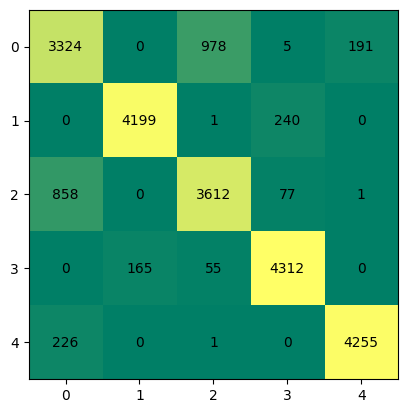

Classification results using MLP:
Test accuracy of MLP:  0.8827
Computation time: 0.5007 s
              precision    recall  f1-score   support

           0       0.80      0.71      0.75      4498
           1       0.96      0.95      0.96      4440
           2       0.76      0.86      0.81      4548
           3       0.94      0.94      0.94      4532
           4       0.97      0.95      0.96      4482

    accuracy                           0.88     22500
   macro avg       0.88      0.88      0.88     22500
weighted avg       0.88      0.88      0.88     22500



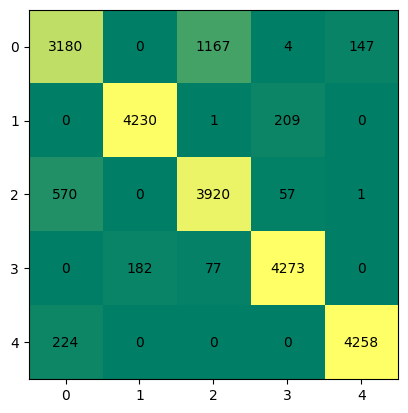

Classification results using AdaBoost:
Test accuracy of AdaBoost:  0.7018
Computation time: 0.1953 s
              precision    recall  f1-score   support

           0       0.78      0.72      0.75      4498
           1       0.00      0.00      0.00      4440
           2       0.77      0.84      0.80      4548
           3       0.50      0.99      0.66      4532
           4       0.96      0.95      0.96      4482

    accuracy                           0.70     22500
   macro avg       0.60      0.70      0.63     22500
weighted avg       0.60      0.70      0.64     22500



C:\Users\Reign\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Reign\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Reign\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

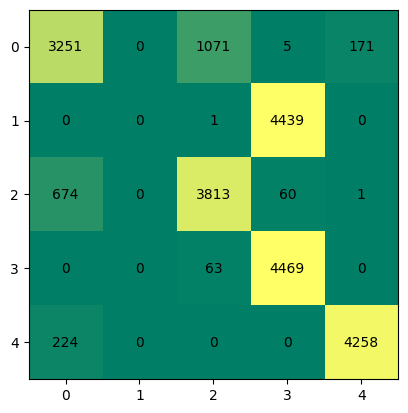

Classification results using SVM:
Test accuracy of SVM:  0.8860
Computation time: 7.9327 s
              precision    recall  f1-score   support

           0       0.79      0.75      0.77      4498
           1       0.97      0.94      0.96      4440
           2       0.79      0.82      0.81      4548
           3       0.93      0.95      0.94      4532
           4       0.96      0.96      0.96      4482

    accuracy                           0.89     22500
   macro avg       0.89      0.89      0.89     22500
weighted avg       0.89      0.89      0.89     22500



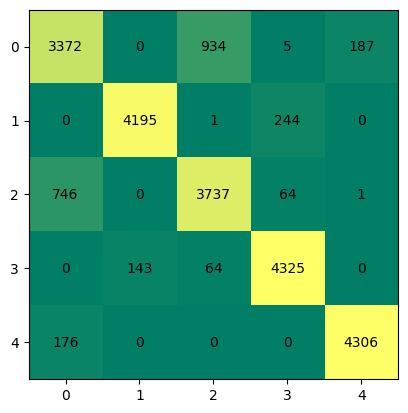

Classification results using Random Forest:
Test accuracy of Random Forest:  0.8874
Computation time: 0.6482 s
              precision    recall  f1-score   support

           0       0.78      0.75      0.77      4498
           1       0.97      0.94      0.96      4440
           2       0.79      0.83      0.81      4548
           3       0.93      0.96      0.95      4532
           4       0.96      0.96      0.96      4482

    accuracy                           0.89     22500
   macro avg       0.89      0.89      0.89     22500
weighted avg       0.89      0.89      0.89     22500



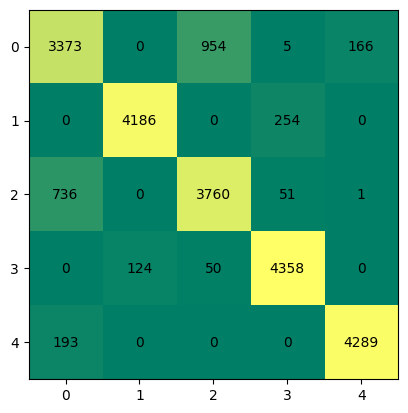

In [ ]:
# Evaluate models with best parameters on test data using all classifiers
for model_name, best_model in best_models.items():
    # Measure computation time of each model
    start = time.time()
    Y_pred = best_model.predict(X_test)
    end = time.time()

    print(f"Classification results using {model_name}:")
    print(f"Test accuracy of {model_name}: {accuracy_score(Y_test, Y_pred): .4f}")  # Print accuracy
    print(f"Computation time: {np.round(end - start, 4)} s")  # Print the computation time
    print(classification_report(Y_test, Y_pred))  # Print the classification report

    # Print the confusion matrix per classifier results
    plt.imshow(confusion_matrix(Y_test, Y_pred), cmap = "summer")
    for i in range(len(confusion_matrix(Y_test, Y_pred))):
        for j in range(len(confusion_matrix(Y_test, Y_pred))):
            plt.text(j, i, str(int(confusion_matrix(Y_test, Y_pred)[i, j])), ha = "center", va = "center", color = "black")
    plt.savefig(f"12_{model_name}_confusion_matrix.png")
    plt.show()


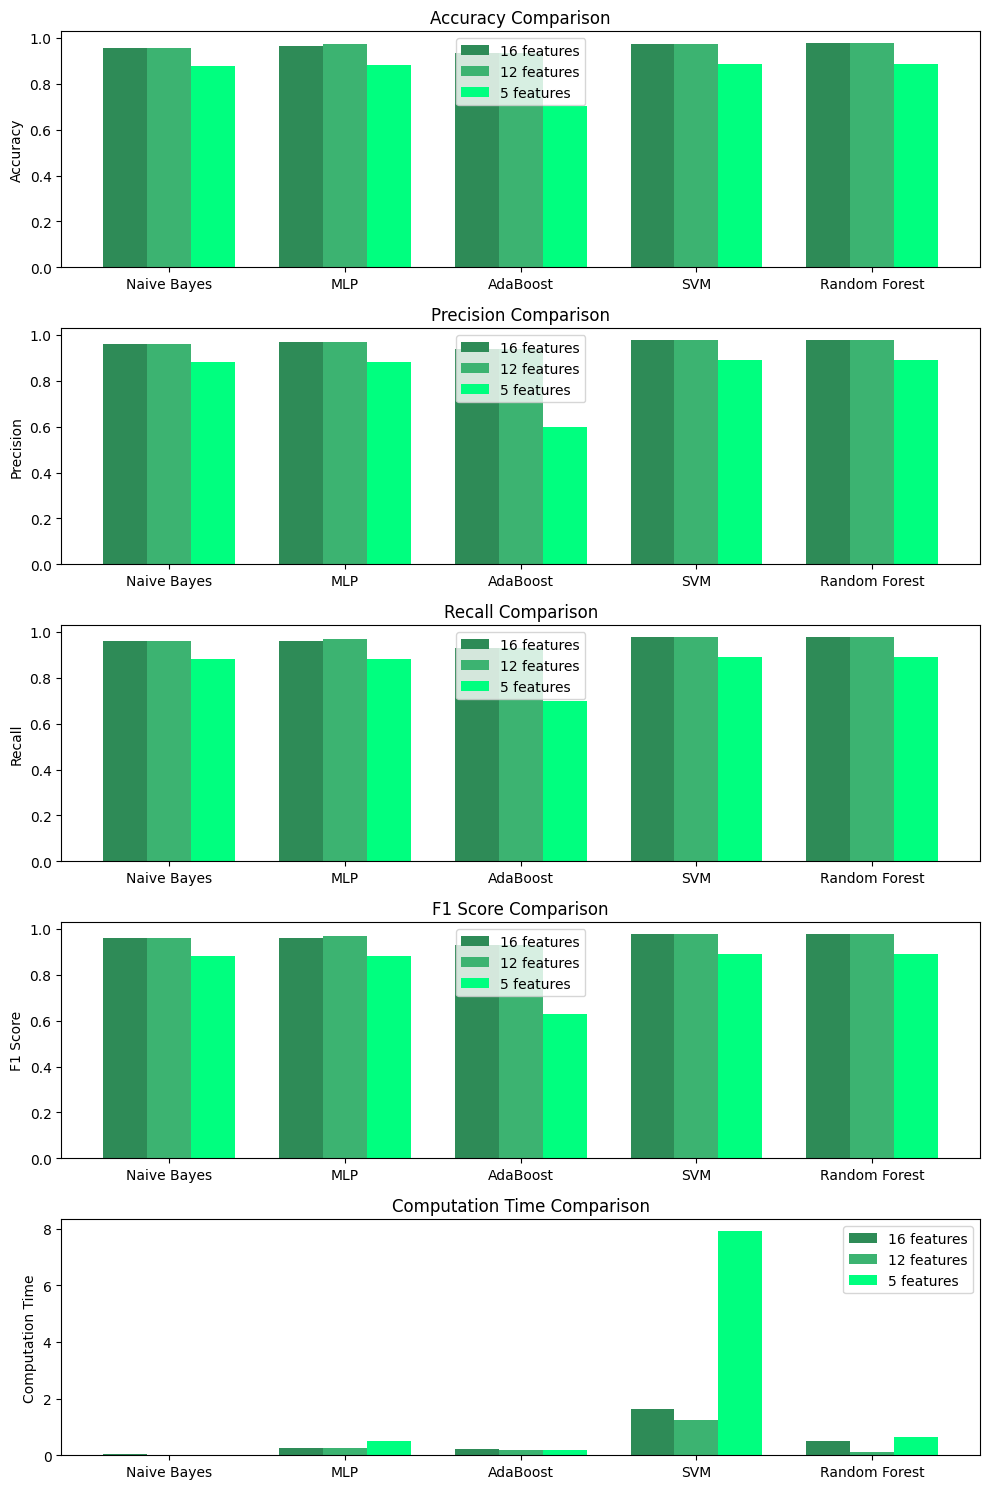

In [ ]:
# Bar graphs for comparison of 16 vs 12 vs 5 features

# Create list of models and metric labels
models = ["Naive Bayes", "MLP", "AdaBoost", "SVM", "Random Forest"]
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "Computation Time"]

# Create dicitonary of the values per metric, per set of results
features_16 = {"Accuracy": [0.9578, 0.9645, 0.9325, 0.9758, 0.9799],
    "Precision": [0.96, 0.97, 0.94, 0.98, 0.98],
    "Recall": [0.96, 0.96, 0.93, 0.98, 0.98],
    "F1 Score": [0.96, 0.96, 0.93, 0.98, 0.98],
    "Computation Time": [0.0322, 0.2414, 0.2382, 1.6253, 0.4885]  # in seconds}

features_12 = {"Accuracy": [0.9560, 0.9722, 0.9325, 0.9756, 0.9796],
    "Precision": [0.96, 0.97, 0.94, 0.98, 0.98],
    "Recall": [0.96, 0.97, 0.93, 0.98, 0.98],
    "F1 Score": [0.96, 0.97, 0.93, 0.98, 0.98],
    "Computation Time": [0.0234, 0.2744, 0.1892, 1.2542, 0.1313]  # in seconds}

features_5 = {"Accuracy": [0.8756, 0.8827, 0.7018, 0.8860, 0.8874],
    "Precision": [0.88, 0.88, 0.60, 0.89, 0.89],
    "Recall": [0.88, 0.88, 0.70, 0.89, 0.89],
    "F1 Score": [0.88, 0.88, 0.63, 0.89, 0.89],
    "Computation Time": [0.0214, 0.5007, 0.1953, 7.9327, 0.6482]  # in seconds}

# Create subplots for each metric
fig, axes = plt.subplots(5, 1, figsize = (10, 15))  # 5 plots, one for each metric

# For each metric, generate bar plots comparing results with 16 features, 12 features, and 5 features for each model
for i, metric in enumerate(metrics):
    # Positions of the bar graphs
    x = np.arange(len(models))  # x-axis positions for models
    width = 0.25  # width of the bars

    # Plot bars for the three sets of results
    axes[i].bar(x - width, features_16[metric], width, label = "16 features", color = "seagreen")
    axes[i].bar(x, features_12[metric], width, label = "12 features", color = "mediumseagreen")
    axes[i].bar(x + width, features_5[metric], width, label = "5 features", color = "springgreen")

    # Set labels and titles
    axes[i].set_ylabel(metric)
    axes[i].set_title(f"{metric} Comparison")
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(models)
    axes[i].legend()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig("bar_graphs.png")
plt.show()